Language Model Comparison: RNN (LSTM) vs. Transformer vs. BDH

This notebook implements and compares three language model architectures
for a causal language modeling task (predicting the next token).
1. An RNN-based model (using LSTM)
2. A Transformer-based model
3. The Baby Dragon Hatchling (BDH) model (imported from bdh.py)

We will train all models on the WikiText-2 dataset and evaluate them
on perplexity and time efficiency.


In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from collections import Counter, OrderedDict
from tqdm import tqdm
import re
import time
import math
import sys
from typing import Tuple, List, Dict, Callable
import matplotlib.pyplot as plt
import bdh

In [44]:
def count_parameters(model: nn.Module) -> int:
    """Counts the number of trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 1. Model Definitions


In [45]:
class PositionalEncoding(nn.Module):
    """
    Injects positional information into the input embeddings.
    This is a standard component of the Transformer model.
    """

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        # Register 'pe' as a buffer, so it's not a model parameter
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

In [46]:
class RNNModel(nn.Module):
    """A Causal Language Model based on LSTM."""

    def __init__(
        self,
        vocab_size: int,
        embed_size: int,
        hidden_size: int,
        num_layers: int,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.model_type = "RNN"
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(
            embed_size, hidden_size, num_layers, dropout=dropout, batch_first=False
        )
        self.decoder = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(
        self, src: torch.Tensor, hidden: Tuple[torch.Tensor, torch.Tensor]
    ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        embed = self.dropout(self.embedding(src))
        output, hidden = self.lstm(embed, hidden)
        output = self.dropout(output)
        decoded = self.decoder(output)
        return decoded.view(-1, decoded.size(-1)), hidden

    def init_hidden(self, batch_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Initializes hidden state to zeros."""
        weight = next(self.parameters())
        device = weight.device
        return (
            weight.new_zeros(
                self.num_layers, batch_size, self.hidden_size, device=device
            ),
            weight.new_zeros(
                self.num_layers, batch_size, self.hidden_size, device=device
            ),
        )

In [47]:
class TransformerModel(nn.Module):
    """A Causal Language Model based on TransformerEncoder."""

    def __init__(
        self,
        vocab_size: int,
        embed_size: int,
        nhead: int,
        hidden_size: int,
        num_layers: int,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.model_type = "Transformer"
        self.embed_size = embed_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = PositionalEncoding(embed_size, dropout)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_size,
            nhead=nhead,
            dim_feedforward=hidden_size,
            dropout=dropout,
            batch_first=False,
            activation="gelu",
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers, num_layers, enable_nested_tensor=False
        )
        self.decoder = nn.Linear(embed_size, vocab_size)
        self.src_mask = None

        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def _generate_square_subsequent_mask(
        self, sz: int, device: torch.device
    ) -> torch.Tensor:
        """Generates a causal mask for self-attention."""
        mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        mask = (
            mask.float()
            .masked_fill(mask == 0, float("-inf"))
            .masked_fill(mask == 1, float(0.0))
        )
        return mask

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        device = src.device
        if self.src_mask is None or self.src_mask.size(0) != src.size(0):
            self.src_mask = self._generate_square_subsequent_mask(src.size(0), device)

        src_embed = self.embedding(src) * math.sqrt(self.embed_size)
        src_pos = self.pos_encoder(src_embed)
        output = self.transformer_encoder(src_pos, self.src_mask)
        output = self.decoder(output)
        return output.view(-1, output.size(-1))

## 2. Data Processing


In [48]:
def basic_english_tokenizer(text: str) -> List[str]:
    """
    A simple tokenizer that splits on whitespace and punctuation.
    Approximates torchtext's 'basic_english' tokenizer.
    """
    text = text.lower()
    return re.findall(r"[\w']+|[.,!?;=]", text)

In [49]:
def build_vocab(
    data_iter: iter, tokenizer: Callable
) -> Tuple[Dict[str, int], List[str]]:
    """Builds a vocabulary from a text iterator."""
    counter = Counter()
    for item in tqdm(data_iter, desc="Building vocab"):
        text_content = item.get("text", "")
        if not isinstance(text_content, str) or text_content.strip() == "":
            continue
        counter.update(tokenizer(text_content))

    min_freq = 3
    filtered_tokens = [token for token, count in counter.items() if count >= min_freq]
    sorted_by_freq = sorted(
        filtered_tokens, key=lambda token: counter[token], reverse=True
    )

    ordered_dict = OrderedDict((token, counter[token]) for token in sorted_by_freq)

    specials = [
        "<unk>",
        "<pad>",
        "<bos>",
        "<eos>",
    ]
    vocab_list = specials + list(ordered_dict.keys())

    word_to_idx = {token: i for i, token in enumerate(vocab_list)}
    idx_to_word = vocab_list

    print(f"Built vocab with {len(vocab_list)} tokens (min_freq={min_freq}).")
    return word_to_idx, idx_to_word

In [50]:
def get_data(
    batch_size: int, test_batch_size: int, quick_test: bool, device: torch.device
) -> Tuple[
    torch.Tensor, torch.Tensor, torch.Tensor, Dict[str, int], List[str], Callable
]:
    """Loads and processes the WikiText-2 dataset using Hugging Face datasets."""
    print("Loading data from Hugging Face 'datasets'...")
    dataset = load_dataset("wikitext", "wikitext-2-v1")

    tokenizer = basic_english_tokenizer

    print("Building vocabulary from training data...")
    word_to_idx, idx_to_word = build_vocab(dataset["train"], tokenizer)
    unk_idx = word_to_idx["<unk>"]
    eos_idx = word_to_idx["<eos>"]

    def data_process(raw_data_iter):
        """Converts raw text iterator to a flat tensor of token indices, adding EOS."""
        data = []
        num_empty = 0
        print("Processing data...")
        for item in tqdm(raw_data_iter):
            text_content = item.get("text", "")
            if not isinstance(text_content, str) or text_content.strip() == "":
                num_empty += 1
                continue
            tokens = tokenizer(text_content)
            indices = [word_to_idx.get(token, unk_idx) for token in tokens] + [eos_idx]
            data.append(torch.tensor(indices, dtype=torch.long))
        print(f"Skipped {num_empty} empty/invalid lines.")

        return torch.cat(tuple(filter(lambda t: t.numel() > 0, data)))

    train_data_flat = data_process(dataset["train"])
    val_data_flat = data_process(dataset["validation"])
    test_data_flat = data_process(dataset["test"])

    if quick_test:
        print("--- QUICK TEST MODE: Using tiny data subset ---")

        train_data_flat = train_data_flat[:20000]
        val_data_flat = val_data_flat[:2000]
        test_data_flat = test_data_flat[:2000]

    def batchify(data: torch.Tensor, bsz: int, device: torch.device) -> torch.Tensor:
        """
        Reshapes the flat data into [seq_len, batch_size] batches.
        """
        num_batches = data.size(0) // bsz

        data = data.narrow(0, 0, num_batches * bsz)

        data = data.view(bsz, num_batches).t().contiguous()
        return data.to(device)

    train_data = batchify(train_data_flat, batch_size, device)
    val_data = batchify(val_data_flat, test_batch_size, device)
    test_data = batchify(test_data_flat, test_batch_size, device)

    print(f"\nData loading complete. Vocab size: {len(word_to_idx)}")
    print(f"Train data shape: {train_data.shape} (seq_len, batch_size)")
    print(f"Val data shape: {val_data.shape}")
    print(f"Test data shape: {test_data.shape}")

    return train_data, val_data, test_data, word_to_idx, idx_to_word, tokenizer

In [51]:
def get_batch(
    source: torch.Tensor, i: int, bptt: int
) -> Tuple[torch.Tensor, torch.Tensor]:
    seq_len = min(bptt, len(source) - 1 - i)

    end_idx = i + seq_len
    target_end_idx = i + 1 + seq_len

    if end_idx > source.size(0) or target_end_idx > source.size(0):
        seq_len = len(source) - 1 - i
        data = source[i : i + seq_len]
        target = source[i + 1 : i + 1 + seq_len].reshape(-1)
        if data.numel() == 0 or target.numel() == 0:
            return torch.empty(
                (0, source.size(1)), dtype=torch.long, device=source.device
            ), torch.empty((0,), dtype=torch.long, device=source.device)

    else:
        data = source[i:end_idx]
        target = source[i + 1 : target_end_idx].reshape(-1)

    return data, target

## 3. Training & Evaluation Loops


In [52]:
def repackage_hidden(h):
    """Wraps hidden states in new Tensors, to detach them from their history."""
    if isinstance(h, torch.Tensor):
        return h.detach()
    else:
        return tuple(repackage_hidden(v) for v in h)

In [53]:
def train_model(
    model: nn.Module,
    epoch_num: int,
    train_data: torch.Tensor,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: optim.lr_scheduler._LRScheduler,
    vocab_size: int,
    bptt: int,
    clip_value: float,
    model_type: str,
):
    """Runs one epoch of training, adapted for different model types."""
    model.train()
    total_loss = 0.0
    start_time = time.time()
    batch_size = train_data.size(1)

    if model_type == "RNN":
        hidden = model.init_hidden(batch_size)

    batch_indices = range(0, train_data.size(0) - 1, bptt)
    pbar = tqdm(
        batch_indices,
        desc=f"Epoch {epoch_num} Training ({model_type})",
        total=len(batch_indices),
        leave=False,
    )
    num_batches_processed = 0

    for i in pbar:
        data, targets = get_batch(train_data, i, bptt)

        if data.numel() == 0:
            continue

        optimizer.zero_grad()

        loss = None
        if model_type == "RNN":
            hidden = repackage_hidden(hidden)
            output_logits, hidden = model(data, hidden)
            if output_logits.numel() > 0 and targets.numel() > 0:
                loss = criterion(output_logits, targets)
        elif model_type == "Transformer":
            output_logits = model(data)
            if output_logits.numel() > 0 and targets.numel() > 0:
                loss = criterion(output_logits, targets)
        elif model_type == "BDH":
            data_t = data.transpose(0, 1)

            targets_t = targets.view(data.size(1), data.size(0))
            _, loss = model(data_t, targets_t)
        else:
            raise ValueError(f"Unknown model type: {model_type}")

        if loss is not None and torch.isfinite(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()
            total_loss += loss.item()
            num_batches_processed += 1
        elif loss is not None:
            print(
                f"Warning: Non-finite loss encountered: {loss.item()}. Skipping batch {i}."
            )

        if num_batches_processed > 0:
            current_loss = total_loss / num_batches_processed

            batch_loss_val = (
                loss.item()
                if loss is not None and torch.isfinite(loss)
                else float("nan")
            )
            batch_ppl = (
                math.exp(batch_loss_val)
                if not math.isnan(batch_loss_val) and batch_loss_val < 700
                else float("inf")
            )
            pbar.set_postfix(
                batch_loss=f"{batch_loss_val:.2f}",
                batch_ppl=f"{batch_ppl:.2f}",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )
        else:
            pbar.set_postfix(
                batch_loss="N/A",
                batch_ppl="N/A",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )

    if num_batches_processed > 0:
        avg_loss = total_loss / num_batches_processed
        avg_ppl = math.exp(avg_loss) if avg_loss < 700 else float("inf")
    else:
        avg_loss = float("nan")
        avg_ppl = float("nan")

    if not isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step()

    return avg_loss, avg_ppl

In [54]:
def evaluate(
    model: nn.Module,
    eval_data: torch.Tensor,
    criterion: nn.Module,
    vocab_size: int,
    bptt: int,
    model_type: str,
) -> Tuple[float, float]:
    """Evaluates the model on the evaluation data, adapted for model types."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    batch_size = eval_data.size(1)

    if model_type == "RNN":
        hidden = model.init_hidden(batch_size)

    batch_indices = range(0, eval_data.size(0) - 1, bptt)
    pbar = tqdm(
        batch_indices,
        desc=f"Evaluating ({model_type})",
        total=len(batch_indices),
        leave=False,
    )

    with torch.no_grad():
        for i in pbar:
            data, targets = get_batch(eval_data, i, bptt)
            if data.numel() == 0:
                continue

            loss = None
            if model_type == "RNN":
                output_logits, hidden = model(data, hidden)
                hidden = repackage_hidden(hidden)
                if output_logits.numel() > 0 and targets.numel() > 0:
                    loss = criterion(output_logits, targets)
            elif model_type == "Transformer":
                output_logits = model(data)
                if output_logits.numel() > 0 and targets.numel() > 0:
                    loss = criterion(output_logits, targets)
            elif model_type == "BDH":
                data_t = data.transpose(0, 1)
                targets_t = targets.view(data.size(1), data.size(0))
                _, loss = model(data_t, targets_t)
            else:
                raise ValueError(f"Unknown model type: {model_type}")

            if loss is not None and torch.isfinite(loss):
                total_loss += loss.item() * targets.numel()
                total_tokens += targets.numel()
                pbar.set_postfix(batch_loss=f"{loss.item():.2f}")
            elif loss is not None:
                print(
                    f"Warning: Non-finite loss during evaluation: {loss.item()}. Skipping batch."
                )

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss) if avg_loss < 700 else float("inf")
    return avg_loss, perplexity

## 4. Inference


In [55]:
def generate_text(
    model: nn.Module,
    prompt: str,
    max_len: int,
    tokenizer: callable,
    vocab_map: dict,
    idx_to_word: list,
    device: torch.device,
    model_type: str,
):
    """Generates text completion for a given prompt, adapted for model types."""
    model.eval()

    tokens = tokenizer(prompt)
    unk_idx = vocab_map["<unk>"]
    token_indices = [vocab_map.get(t, unk_idx) for t in tokens]

    input_tensor_flat = torch.tensor(token_indices, dtype=torch.long, device=device)

    generated_indices = list(token_indices)

    if model_type == "RNN":
        input_rnn = input_tensor_flat.unsqueeze(1)
        hidden = model.init_hidden(1)
        _, hidden = model(input_rnn, hidden)
        current_input = input_rnn[-1, :].unsqueeze(0)
    elif model_type == "Transformer":
        current_input_seq = input_tensor_flat.unsqueeze(1)
    elif model_type == "BDH":
        current_input_seq_bdh = input_tensor_flat.unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_len):
            if model_type == "RNN":
                output_logits, hidden = model(current_input, hidden)
                next_token_logits = output_logits.squeeze()
                next_token_idx = next_token_logits.argmax().item()

                current_input = torch.tensor(
                    [[next_token_idx]], dtype=torch.long, device=device
                )

            elif model_type == "Transformer":
                output_logits_flat = model(current_input_seq)

                next_token_logits = output_logits_flat[-1, :]
                next_token_idx = next_token_logits.argmax().item()

                next_token_tensor = torch.tensor(
                    [[next_token_idx]], dtype=torch.long, device=device
                )
                current_input_seq = torch.cat(
                    (current_input_seq, next_token_tensor), dim=0
                )

            elif model_type == "BDH":
                logits_flat, _ = model(current_input_seq_bdh)

                B, T_current = current_input_seq_bdh.shape
                logits = logits_flat.view(B, T_current, -1)
                next_token_logits = logits[:, -1, :]
                next_token_idx = next_token_logits.argmax(dim=-1).item()

                next_token_tensor = torch.tensor(
                    [[next_token_idx]], dtype=torch.long, device=device
                )
                current_input_seq_bdh = torch.cat(
                    (current_input_seq_bdh, next_token_tensor), dim=1
                )

            else:
                raise ValueError(f"Unknown model type: {model_type}")

            generated_indices.append(next_token_idx)

            if next_token_idx == vocab_map.get("<eos>", -1):
                break

    return " ".join([idx_to_word[i] for i in generated_indices])

## 5. Main Execution


In [56]:
QUICK_TEST = False
MODEL_TO_RUN = "both"


# "Full Run" parameters - Adjusted for fairer parameter count comparison (~25-28M)
epochs = 15
batch_size = 32
test_batch_size = 16
bptt = 35
embed_size = 256
# RNN (~24.8M params)
hidden_size_rnn = 512
num_layers_rnn = 3
lr_rnn = 15.0
# Transformer (~25.9M params)
nhead_transformer = 4
hidden_size_transformer = 2048
num_layers_transformer = 8
lr_transformer = 0.0002
# BDH (~28.0M params) - Kept original settings
n_head_bdh = 4
mlp_internal_dim_multiplier = 64
num_layers_bdh = 4
lr_bdh = 0.0003
# Shared
clip_value = 0.2  # Gradient clipping value
dropout = 0.5  # Dropout rate
weight_decay = 0.01  # Weight decay for AdamW optimizers (Trans, BDH)

In [57]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


if device.type == "cpu":
    print("Warning: Running on CPU. This will be very slow.")
    if sys.platform == "darwin" and not torch.backends.mps.is_available():
        print(
            "MPS (Apple Silicon GPU) not detected. Ensure PyTorch >= 1.12 is installed."
        )
print(f"Using device: {device}")

Using device: mps


In [58]:
train_data, val_data, test_data, word_to_idx, idx_to_word, tokenizer = get_data(
    batch_size, test_batch_size, QUICK_TEST, device
)
vocab_size = len(word_to_idx)


bdh_config = bdh.BDHConfig(
    n_layer=num_layers_bdh if not QUICK_TEST else 2,
    n_embd=embed_size,
    dropout=dropout,
    n_head=n_head_bdh if not QUICK_TEST else 2,
    mlp_internal_dim_multiplier=mlp_internal_dim_multiplier if not QUICK_TEST else 32,
    vocab_size=vocab_size,
)

Loading data from Hugging Face 'datasets'...
Building vocabulary from training data...


Building vocab: 100%|██████████| 36718/36718 [00:00<00:00, 69179.79it/s]


Built vocab with 28752 tokens (min_freq=3).
Processing data...


100%|██████████| 36718/36718 [00:00<00:00, 49491.45it/s]


Skipped 12951 empty/invalid lines.
Processing data...


100%|██████████| 3760/3760 [00:00<00:00, 48997.81it/s]


Skipped 1299 empty/invalid lines.
Processing data...


100%|██████████| 4358/4358 [00:00<00:00, 50725.06it/s]


Skipped 1467 empty/invalid lines.

Data loading complete. Vocab size: 28752
Train data shape: torch.Size([62421, 32]) (seq_len, batch_size)
Val data shape: torch.Size([13063, 16])
Test data shape: torch.Size([14702, 16])


In [59]:
prompts = [
    "The best way to",
    "Once upon a time",
    "In a surprising turn of events",
    "The report concluded that",
    "Technology has changed",
    "The main difference between",
    "When the capital was",
    "He opened the door and",
    "The system is designed to",
    "This research suggests that",
]


results = {
    "RNN": {
        "train_time": 0,
        "test_ppl": float("nan"),
        "inf_time": 0,
        "best_val_ppl": float("inf"),
        "params": 0,
    },
    "Transformer": {
        "train_time": 0,
        "test_ppl": float("nan"),
        "inf_time": 0,
        "best_val_ppl": float("inf"),
        "params": 0,
    },
    "BDH": {
        "train_time": 0,
        "test_ppl": float("nan"),
        "inf_time": 0,
        "best_val_ppl": float("inf"),
        "params": 0,
    },
}

### Run RNN (LSTM) Model



Initializing RNN (LSTM) Model
Params: embed=256, hidden=512, layers=3
Number of trainable parameters: 27,889,744

--- Epoch 1/15 ---


--------------------------------------------------------------------------------
| end of epoch   1 | time: 126.77s | valid loss  6.02 | valid ppl   411.31
--------------------------------------------------------------------------------
New best RNN model found! Val PPL: 411.31. Saving to 'best_rnn_model.pt'

--- Epoch 2/15 ---


--------------------------------------------------------------------------------
| end of epoch   2 | time: 127.75s | valid loss  5.63 | valid ppl   279.91
--------------------------------------------------------------------------------
New best RNN model found! Val PPL: 279.91. Saving to 'best_rnn_model.pt'

--- Epoch 3/15 ---


--------------------------------------------------------------------------------
| end of epoch   3 | time: 125.44s | valid loss  5.46 | valid ppl   236.26
--------------------------------------------------------------------------------
New best RNN model found! Val PPL: 236.26. Saving to 'best_rnn_model.pt'

--- Epoch 4/15 ---


--------------------------------------------------------------------------------
| end of epoch   4 | time: 125.08s | valid loss  5.35 | valid ppl   210.17
--------------------------------------------------------------------------------
New best RNN model found! Val PPL: 210.17. Saving to 'best_rnn_model.pt'

--- Epoch 5/15 ---


...

--------------------------------------------------------------------------------
| end of epoch  11 | time: 126.22s | valid loss  5.13 | valid ppl   169.22
--------------------------------------------------------------------------------
New best RNN model found! Val PPL: 169.22. Saving to 'best_rnn_model.pt'

--- Epoch 12/15 ---


--------------------------------------------------------------------------------
| end of epoch  12 | time: 123.75s | valid loss  5.13 | valid ppl   168.34
--------------------------------------------------------------------------------
New best RNN model found! Val PPL: 168.34. Saving to 'best_rnn_model.pt'

--- Epoch 13/15 ---


--------------------------------------------------------------------------------
| end of epoch  13 | time: 123.74s | valid loss  5.13 | valid ppl   169.37
--------------------------------------------------------------------------------

--- Epoch 14/15 ---


--------------------------------------------------------------------------------
| end of epoch  14 | time: 124.12s | valid loss  5.11 | valid ppl   165.48
--------------------------------------------------------------------------------
New best RNN model found! Val PPL: 165.48. Saving to 'best_rnn_model.pt'

--- Epoch 15/15 ---


--------------------------------------------------------------------------------
| end of epoch  15 | time: 125.16s | valid loss  5.12 | valid ppl   166.51
--------------------------------------------------------------------------------


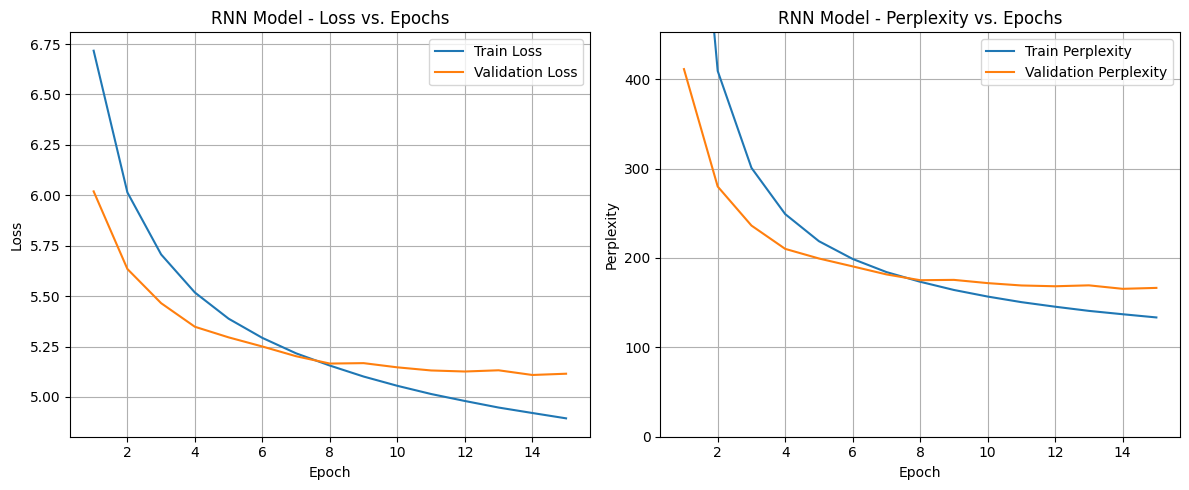


--- RNN Final Evaluation ---
Total Training Time: 1879.18 seconds
Loaded best saved model for testing.


Test Loss: 5.06 | Test Perplexity: 157.25

--- RNN Inference ---
PROMPT: The best way to...
OUTPUT: the best way to be the first to be the first to be the first to be the first to be the first to be the first to be the first to be the first to be the first to be the first to be the first to be the first to be the

PROMPT: Once upon a time...
OUTPUT: once upon a time . <eos>

PROMPT: In a surprising turn of events...
OUTPUT: in a surprising turn of events . <eos>

PROMPT: The report concluded that...
OUTPUT: the report concluded that the unk of the unk was the first to be the first to be the first to be the first . <eos>

PROMPT: Technology has changed...
OUTPUT: technology has changed to the unk , and the unk of the unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk

PROMPT: The main difference between...
OUTPUT: the main difference between the unk and unk . <eos>

PROMPT: W

In [60]:
if MODEL_TO_RUN in ["rnn", "both"]:
    print("\n" + "=" * 80)
    print("Initializing RNN (LSTM) Model")
    print(
        f"Params: embed={embed_size}, hidden={hidden_size_rnn}, layers={num_layers_rnn}"
    )

    model_rnn = RNNModel(
        vocab_size, embed_size, hidden_size_rnn, num_layers_rnn, dropout
    ).to(device)
    num_params_rnn = count_parameters(model_rnn)
    results["RNN"]["params"] = num_params_rnn
    print(f"Number of trainable parameters: {num_params_rnn:,}")
    print("=" * 80)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_rnn.parameters(), lr=lr_rnn)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, "min", factor=0.5, patience=2
    )

    best_val_loss = float("inf")
    total_train_time = 0.0

    rnn_train_losses, rnn_val_losses, rnn_train_ppls, rnn_val_ppls = [], [], [], []

    try:
        for epoch in range(1, epochs + 1):
            epoch_start_time = time.time()

            print(f"\n--- Epoch {epoch}/{epochs} ---")
            train_loss, train_ppl = train_model(
                model_rnn,
                epoch,
                train_data,
                criterion,
                optimizer,
                scheduler,
                vocab_size,
                bptt,
                clip_value,
                model_type="RNN",
            )

            val_loss, val_ppl = evaluate(
                model_rnn, val_data, criterion, vocab_size, bptt, model_type="RNN"
            )

            epoch_time = time.time() - epoch_start_time
            total_train_time += epoch_time

            rnn_train_losses.append(train_loss)
            rnn_train_ppls.append(train_ppl)
            rnn_val_losses.append(val_loss)
            rnn_val_ppls.append(val_ppl)

            print("-" * 80)
            print(
                f"| end of epoch {epoch:3d} | time: {epoch_time:5.2f}s | "
                f"valid loss {val_loss:5.2f} | valid ppl {val_ppl:8.2f}"
            )
            print("-" * 80)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                results["RNN"]["best_val_ppl"] = val_ppl
                print(
                    f"New best RNN model found! Val PPL: {val_ppl:.2f}. Saving to 'best_rnn_model.pt'"
                )
                torch.save(model_rnn.state_dict(), "best_rnn_model.pt")

            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)

    except KeyboardInterrupt:
        print("\nRNN Training interrupted by user.")

    if rnn_train_losses:
        plt.figure(figsize=(12, 5))
        epochs_range = range(1, len(rnn_train_losses) + 1)

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, rnn_train_losses, label="Train Loss")
        plt.plot(epochs_range, rnn_val_losses, label="Validation Loss")
        plt.title("RNN Model - Loss vs. Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, rnn_train_ppls, label="Train Perplexity")
        plt.plot(epochs_range, rnn_val_ppls, label="Validation Perplexity")
        plt.title("RNN Model - Perplexity vs. Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Perplexity")
        if rnn_val_ppls:
            plt.ylim(bottom=0, top=min(max(rnn_val_ppls) * 1.1, 2000))
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    print("\n--- RNN Final Evaluation ---")
    results["RNN"]["train_time"] = total_train_time
    print(f"Total Training Time: {total_train_time:.2f} seconds")

    try:
        model_rnn.load_state_dict(torch.load("best_rnn_model.pt", map_location=device))
        print("Loaded best saved model for testing.")
        test_loss, test_ppl = evaluate(
            model_rnn, test_data, criterion, vocab_size, bptt, model_type="RNN"
        )
        results["RNN"]["test_ppl"] = test_ppl
        print(f"Test Loss: {test_loss:.2f} | Test Perplexity: {test_ppl:.2f}")
    except FileNotFoundError:
        print("No 'best_rnn_model.pt' found. Skipping final test.")
        test_ppl = float("nan")

    print("\n--- RNN Inference ---")
    if not math.isnan(test_ppl):
        inference_start_time = time.time()
        for prompt in prompts:
            generated = generate_text(
                model_rnn,
                prompt,
                50,
                tokenizer,
                word_to_idx,
                idx_to_word,
                device,
                model_type="RNN",
            )
            print(f"PROMPT: {prompt}...")
            print(f"OUTPUT: {generated}\n")
        inference_time = time.time() - inference_start_time
        results["RNN"]["inf_time"] = inference_time
        print(f"Total Inference Time (10 prompts): {inference_time:.2f} seconds")
    else:
        print("Skipping inference as no model was loaded/tested.")

### Run Transformer Model



Initializing Transformer Model
Params: embed=256, nhead=4, hidden=2048, layers=8
Number of trainable parameters: 25,270,352

--- Epoch 1/15 ---


--------------------------------------------------------------------------------
| end of epoch   1 | time: 170.06s | valid loss  6.01 | valid ppl   407.27
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 407.27. Saving to 'best_transformer_model.pt'

--- Epoch 2/15 ---


--------------------------------------------------------------------------------
| end of epoch   2 | time: 168.69s | valid loss  5.82 | valid ppl   336.56
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 336.56. Saving to 'best_transformer_model.pt'

--- Epoch 3/15 ---


--------------------------------------------------------------------------------
| end of epoch   3 | time: 168.96s | valid loss  5.70 | valid ppl   299.35
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 299.35. Saving to 'best_transformer_model.pt'

--- Epoch 4/15 ---


--------------------------------------------------------------------------------
| end of epoch   4 | time: 168.59s | valid loss  5.62 | valid ppl   276.69
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 276.69. Saving to 'best_transformer_model.pt'

--- Epoch 5/15 ---


...

--------------------------------------------------------------------------------
| end of epoch  11 | time: 169.47s | valid loss  5.32 | valid ppl   205.15
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 205.15. Saving to 'best_transformer_model.pt'

--- Epoch 12/15 ---


--------------------------------------------------------------------------------
| end of epoch  12 | time: 168.22s | valid loss  5.31 | valid ppl   201.86
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 201.86. Saving to 'best_transformer_model.pt'

--- Epoch 13/15 ---


--------------------------------------------------------------------------------
| end of epoch  13 | time: 169.68s | valid loss  5.29 | valid ppl   198.43
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 198.43. Saving to 'best_transformer_model.pt'

--- Epoch 14/15 ---


--------------------------------------------------------------------------------
| end of epoch  14 | time: 177.05s | valid loss  5.28 | valid ppl   196.48
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 196.48. Saving to 'best_transformer_model.pt'

--- Epoch 15/15 ---


--------------------------------------------------------------------------------
| end of epoch  15 | time: 178.96s | valid loss  5.26 | valid ppl   193.12
--------------------------------------------------------------------------------
New best Transformer model found! Val PPL: 193.12. Saving to 'best_transformer_model.pt'


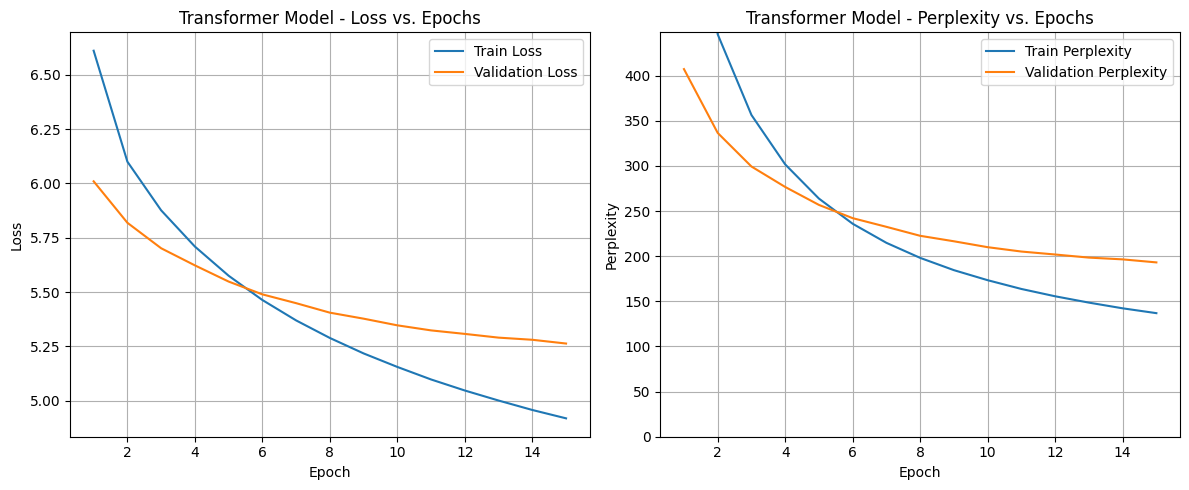


--- Transformer Final Evaluation ---
Total Training Time: 2550.82 seconds
Loaded best saved model for testing.


Test Loss: 5.20 | Test Perplexity: 180.97

--- Transformer Inference ---
PROMPT: The best way to...
OUTPUT: the best way to be a series of the series . <eos>

PROMPT: Once upon a time...
OUTPUT: once upon a time , he was unable to be able to be a unk . <eos>

PROMPT: In a surprising turn of events...
OUTPUT: in a surprising turn of events . <eos>

PROMPT: The report concluded that...
OUTPUT: the report concluded that the jin had been the first army of the jin , and the jin had been captured by the jin . <eos>

PROMPT: Technology has changed...
OUTPUT: technology has changed to the unk of the unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk unk

PROMPT: The main difference between...
OUTPUT: the main difference between the nasals and the nasals are not used to be used . <eos>

PROMPT: When the capital was...
OUTPUT: when the capital was not able to be able to be

In [61]:
if MODEL_TO_RUN in ["transformer", "both"]:
    print("\n" + "=" * 80)
    print("Initializing Transformer Model")
    print(
        f"Params: embed={embed_size}, nhead={nhead_transformer}, hidden={hidden_size_transformer}, layers={num_layers_transformer}"
    )

    model_transformer = TransformerModel(
        vocab_size,
        embed_size,
        nhead_transformer,
        hidden_size_transformer,
        num_layers_transformer,
        dropout,
    ).to(device)
    num_params_transformer = count_parameters(model_transformer)
    results["Transformer"]["params"] = num_params_transformer
    print(f"Number of trainable parameters: {num_params_transformer:,}")
    print("=" * 80)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model_transformer.parameters(), lr=lr_transformer, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)

    best_val_loss = float("inf")
    total_train_time = 0.0

    (
        transformer_train_losses,
        transformer_val_losses,
        transformer_train_ppls,
        transformer_val_ppls,
    ) = [], [], [], []

    try:
        for epoch in range(1, epochs + 1):
            epoch_start_time = time.time()

            print(f"\n--- Epoch {epoch}/{epochs} ---")
            train_loss, train_ppl = train_model(
                model_transformer,
                epoch,
                train_data,
                criterion,
                optimizer,
                scheduler,
                vocab_size,
                bptt,
                clip_value,
                model_type="Transformer",
            )

            val_loss, val_ppl = evaluate(
                model_transformer,
                val_data,
                criterion,
                vocab_size,
                bptt,
                model_type="Transformer",
            )

            epoch_time = time.time() - epoch_start_time
            total_train_time += epoch_time

            transformer_train_losses.append(train_loss)
            transformer_train_ppls.append(train_ppl)
            transformer_val_losses.append(val_loss)
            transformer_val_ppls.append(val_ppl)

            print("-" * 80)
            print(
                f"| end of epoch {epoch:3d} | time: {epoch_time:5.2f}s | "
                f"valid loss {val_loss:5.2f} | valid ppl {val_ppl:8.2f}"
            )
            print("-" * 80)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                results["Transformer"]["best_val_ppl"] = val_ppl
                print(
                    f"New best Transformer model found! Val PPL: {val_ppl:.2f}. Saving to 'best_transformer_model.pt'"
                )
                torch.save(model_transformer.state_dict(), "best_transformer_model.pt")

            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)

    except KeyboardInterrupt:
        print("\nTransformer Training interrupted by user.")

    if transformer_train_losses:
        plt.figure(figsize=(12, 5))
        epochs_range = range(1, len(transformer_train_losses) + 1)

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, transformer_train_losses, label="Train Loss")
        plt.plot(epochs_range, transformer_val_losses, label="Validation Loss")
        plt.title("Transformer Model - Loss vs. Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, transformer_train_ppls, label="Train Perplexity")
        plt.plot(epochs_range, transformer_val_ppls, label="Validation Perplexity")
        plt.title("Transformer Model - Perplexity vs. Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Perplexity")
        if transformer_val_ppls:
            plt.ylim(bottom=0, top=min(max(transformer_val_ppls) * 1.1, 2000))
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    print("\n--- Transformer Final Evaluation ---")
    results["Transformer"]["train_time"] = total_train_time
    print(f"Total Training Time: {total_train_time:.2f} seconds")
    try:
        model_transformer.load_state_dict(
            torch.load("best_transformer_model.pt", map_location=device)
        )
        print("Loaded best saved model for testing.")
        test_loss, test_ppl = evaluate(
            model_transformer,
            test_data,
            criterion,
            vocab_size,
            bptt,
            model_type="Transformer",
        )
        results["Transformer"]["test_ppl"] = test_ppl
        print(f"Test Loss: {test_loss:.2f} | Test Perplexity: {test_ppl:.2f}")
    except FileNotFoundError:
        print("No 'best_transformer_model.pt' found. Skipping final test.")
        test_ppl = float("nan")

    print("\n--- Transformer Inference ---")
    if not math.isnan(test_ppl):
        inference_start_time = time.time()
        for prompt in prompts:
            generated = generate_text(
                model_transformer,
                prompt,
                50,
                tokenizer,
                word_to_idx,
                idx_to_word,
                device,
                model_type="Transformer",
            )
            print(f"PROMPT: {prompt}...")
            print(f"OUTPUT: {generated}\n")
        inference_time = time.time() - inference_start_time
        results["Transformer"]["inf_time"] = inference_time
        print(f"Total Inference Time (10 prompts): {inference_time:.2f} seconds")
    else:
        print("Skipping inference as no model was loaded/tested.")

### Run BDH Model



Initializing BDH Model
Params: embed=256, heads=4, layers=4, N_mult=64
Number of trainable parameters: 27,303,936

--- Epoch 1/15 ---


--------------------------------------------------------------------------------
| end of epoch   1 | time: 1233.94s | valid loss  6.79 | valid ppl   893.03
--------------------------------------------------------------------------------
New best BDH model found! Val PPL: 893.03. Saving to 'best_bdh_model.pt'

--- Epoch 2/15 ---


--------------------------------------------------------------------------------
| end of epoch   2 | time: 1306.45s | valid loss  6.84 | valid ppl   932.20
--------------------------------------------------------------------------------

--- Epoch 3/15 ---


--------------------------------------------------------------------------------
| end of epoch   3 | time: 1241.34s | valid loss  6.87 | valid ppl   961.01
--------------------------------------------------------------------------------

--- Epoch 4/15 ---


--------------------------------------------------------------------------------
| end of epoch   4 | time: 1157.90s | valid loss  6.91 | valid ppl   999.69
--------------------------------------------------------------------------------

--- Epoch 5/15 ---



BDH Training interrupted by user.


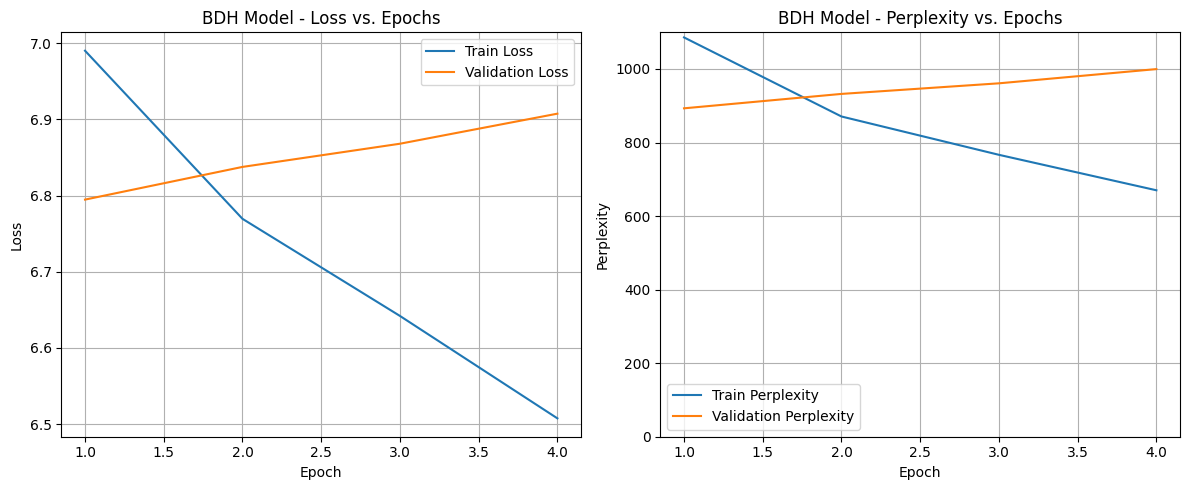


--- BDH Final Evaluation ---
Total Training Time: 4939.64 seconds
Loaded best saved model for testing.


Test Loss: 6.74 | Test Perplexity: 846.99

--- BDH Inference ---
PROMPT: The best way to...
OUTPUT: the best way to the , the , the , the , the , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,

PROMPT: Once upon a time...
OUTPUT: once upon a time , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,

PROMPT: In a surprising turn of events...
OUTPUT: in a surprising turn of events the , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,

PROMPT: The report concluded that...
OUTPUT: the report concluded that the , the , the , the , the , the , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,

PROMPT: Technology has changed...
OUTPUT: technology has changed , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,

PROMPT: The main difference between...
OUTPUT: the main difference between the , the 

In [62]:
if MODEL_TO_RUN in ["bdh", "both"]:
    print("\n" + "=" * 80)
    print("Initializing BDH Model")
    print(
        f"Params: embed={bdh_config.n_embd}, heads={bdh_config.n_head}, layers={bdh_config.n_layer}, N_mult={bdh_config.mlp_internal_dim_multiplier}"
    )

    model_bdh = bdh.BDH(bdh_config).to(device)
    num_params_bdh = count_parameters(model_bdh)
    results["BDH"]["params"] = num_params_bdh
    print(f"Number of trainable parameters: {num_params_bdh:,}")
    print("=" * 80)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model_bdh.parameters(), lr=lr_bdh, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)

    best_val_loss = float("inf")
    total_train_time = 0.0

    bdh_train_losses, bdh_val_losses, bdh_train_ppls, bdh_val_ppls = [], [], [], []

    try:
        for epoch in range(1, epochs + 1):
            epoch_start_time = time.time()

            print(f"\n--- Epoch {epoch}/{epochs} ---")

            train_loss, train_ppl = train_model(
                model_bdh,
                epoch,
                train_data,
                criterion,
                optimizer,
                scheduler,
                vocab_size,
                bptt,
                clip_value,
                model_type="BDH",
            )

            val_loss, val_ppl = evaluate(
                model_bdh, val_data, criterion, vocab_size, bptt, model_type="BDH"
            )

            epoch_time = time.time() - epoch_start_time
            total_train_time += epoch_time

            bdh_train_losses.append(train_loss)
            bdh_train_ppls.append(train_ppl)
            bdh_val_losses.append(val_loss)
            bdh_val_ppls.append(val_ppl)

            print("-" * 80)
            print(
                f"| end of epoch {epoch:3d} | time: {epoch_time:5.2f}s | "
                f"valid loss {val_loss:5.2f} | valid ppl {val_ppl:8.2f}"
            )
            print("-" * 80)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                results["BDH"]["best_val_ppl"] = val_ppl
                print(
                    f"New best BDH model found! Val PPL: {val_ppl:.2f}. Saving to 'best_bdh_model.pt'"
                )
                torch.save(model_bdh.state_dict(), "best_bdh_model.pt")

            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)

    except KeyboardInterrupt:
        print("\nBDH Training interrupted by user.")

    if bdh_train_losses:
        plt.figure(figsize=(12, 5))
        epochs_range = range(1, len(bdh_train_losses) + 1)

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, bdh_train_losses, label="Train Loss")
        plt.plot(epochs_range, bdh_val_losses, label="Validation Loss")
        plt.title("BDH Model - Loss vs. Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, bdh_train_ppls, label="Train Perplexity")
        plt.plot(epochs_range, bdh_val_ppls, label="Validation Perplexity")
        plt.title("BDH Model - Perplexity vs. Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Perplexity")
        if bdh_val_ppls:
            plt.ylim(bottom=0, top=min(max(bdh_val_ppls) * 1.1, 2000))
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    print("\n--- BDH Final Evaluation ---")
    results["BDH"]["train_time"] = total_train_time
    print(f"Total Training Time: {total_train_time:.2f} seconds")
    try:
        model_bdh.load_state_dict(torch.load("best_bdh_model.pt", map_location=device))
        print("Loaded best saved model for testing.")
        test_loss, test_ppl = evaluate(
            model_bdh, test_data, criterion, vocab_size, bptt, model_type="BDH"
        )
        results["BDH"]["test_ppl"] = test_ppl
        print(f"Test Loss: {test_loss:.2f} | Test Perplexity: {test_ppl:.2f}")
    except FileNotFoundError:
        print("No 'best_bdh_model.pt' found. Skipping final test.")
        test_ppl = float("nan")

    print("\n--- BDH Inference ---")
    if not math.isnan(test_ppl):
        inference_start_time = time.time()
        for prompt in prompts:
            generated = generate_text(
                model_bdh,
                prompt,
                50,
                tokenizer,
                word_to_idx,
                idx_to_word,
                device,
                model_type="BDH",
            )
            print(f"PROMPT: {prompt}...")
            print(f"OUTPUT: {generated}\n")
        inference_time = time.time() - inference_start_time
        results["BDH"]["inf_time"] = inference_time
        print(f"Total Inference Time (10 prompts): {inference_time:.2f} seconds")
    else:
        print("Skipping inference as no model was loaded/tested.")

## 6. Final Report Summary


In [63]:
print("\n" + "=" * 80)
print("Final Results Summary")
print("=" * 80)
print(f"{'Metric':<25} | {'RNN (LSTM)':<18} | {'Transformer':<18} | {'BDH':<18}")
print("-" * 80)
print(
    f"{'Trainable Parameters':<25} | {results['RNN']['params']:,<18} | {results['Transformer']['params']:,<18} | {results['BDH']['params']:,<18}"
)
print(
    f"{'Best Valid Perplexity':<25} | {results['RNN']['best_val_ppl']:<18.2f} | {results['Transformer']['best_val_ppl']:<18.2f} | {results['BDH']['best_val_ppl']:<18.2f}"
)
print(
    f"{'Final Test Perplexity':<25} | {results['RNN']['test_ppl']:<18.2f} | {results['Transformer']['test_ppl']:<18.2f} | {results['BDH']['test_ppl']:<18.2f}"
)
print(
    f"{'Total Training Time (s)':<25} | {results['RNN']['train_time']:<18.2f} | {results['Transformer']['train_time']:<18.2f} | {results['BDH']['train_time']:<18.2f}"
)
print(
    f"{'Inference Time (s)':<25} | {results['RNN']['inf_time']:<18.2f} | {results['Transformer']['inf_time']:<18.2f} | {results['BDH']['inf_time']:<18.2f}"
)
print("=" * 80)


Final Results Summary
Metric                    | RNN (LSTM)         | Transformer        | BDH               
--------------------------------------------------------------------------------
Trainable Parameters      | 27889744,,,,,,,,,, | 25270352,,,,,,,,,, | 27303936,,,,,,,,,,
Best Valid Perplexity     | 165.48             | 193.12             | 893.03            
Final Test Perplexity     | 157.25             | 180.97             | 846.99            
Total Training Time (s)   | 1879.18            | 2550.82            | 4939.64           
Inference Time (s)        | 0.30               | 1.61               | 8.83              

